<h1>Prophet package</h1>

In [ ]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from main import *
import numpy as np
from sklearn.metrics import mean_squared_error

In [ ]:
l_min = 4
max_diff = 3
c_thresh = 0.9

df = add_features_and_filter(l_min, max_diff, c_thresh, read_from_integrated=False)

ds = Data_selector(df)
df_modified = ds.select_peaks(goodness=3)

feature_selector = Feature_selector(df_modified, target="generation")
features_to_be_select = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value", "forecast",
                         "status", "season"] + ["datetime"]
feature_selector.select(features_to_select=features_to_be_select)

In [ ]:
preprocessed_df = feature_selector.df
power_plants = preprocessed_df[['name', 'code']].drop_duplicates()
preprocessed_df.rename(columns={"datetime": "ds", "generation": "y"}, inplace=True)

categorical_cols = preprocessed_df.select_dtypes(include=['object', 'category']).columns
categorical_cols = categorical_cols.drop("ds")
preprocessed_df = pd.get_dummies(preprocessed_df, columns=categorical_cols, drop_first=True)
preprocessed_df.columns = preprocessed_df.columns.astype(str)

In [ ]:
test_rmses = []
train_rmses = []

for _, row in power_plants.iterrows():
    mask = (df_modified["name"] == row['name']) & (df_modified['code'] == row['code'])
    
    df_name_code = preprocessed_df[mask]
    test_size = int(len(df_name_code) / 5)
    train_df = df_name_code.iloc[:-test_size]
    test_df = df_name_code.iloc[-test_size:]

    model = Prophet()
    for col in df_name_code.columns:
        if col in ['ds', 'y']: continue
        model.add_regressor(col)
    model.fit(train_df)
    
    future_test = test_df.drop(columns=['y'])
    forecast_test = model.predict(future_test)
    y_true_test = test_df['y'].values
    y_pred_test = forecast_test['yhat'].values

    test_rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test)) / np.mean(y_true_test) * 100
    test_rmses.append(test_rmse)
    print(f"Test Error: {test_rmse:0.2f}%")
    
    future_train = train_df.drop(columns=['y'])
    forecast_train = model.predict(future_train)
    y_true_train = train_df['y'].values
    y_pred_train = forecast_train['yhat'].values
    
    train_rmse = np.sqrt(mean_squared_error(y_true_train, y_pred_train)) / np.mean(y_true_train) * 100
    train_rmses.append(train_rmse)
    print(f"Train Error: {train_rmse:0.2f}%")
    
    

In [2]:
from main import *

In [3]:
l_min = 4
max_diff = 3
c_thresh = 0.9

df = add_features_and_filter(l_min, max_diff, c_thresh, read_from_integrated=False)

ds = Data_selector(df)
df_modified = df.copy()

feature_selector = Feature_selector(df_modified, target="generation")
features_to_be_select = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value", "forecast",
                         "status", "season", "is_good_peak"] + ["datetime"]
feature_selector.select(features_to_select=features_to_be_select)
preprocessed_df = feature_selector.df
power_plants = preprocessed_df[['name', 'code']].drop_duplicates()
preprocessed_df.rename(columns={"datetime": "ds", "generation": "y"}, inplace=True)

categorical_cols = preprocessed_df.select_dtypes(include=['object', 'category']).columns
categorical_cols = categorical_cols.drop("ds")

preprocessed_df = pd.get_dummies(preprocessed_df, columns=categorical_cols, drop_first=True)
preprocessed_df.columns = preprocessed_df.columns.astype(str)

C:\Users\S.H.Jasbi\AppData\Local\Temp\ipykernel_11516\820519628.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  preprocessed_df.rename(columns={"datetime": "ds", "generation": "y"}, inplace=True)


In [8]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

test_rmses = []
train_rmses = []
exog_columns = None
# features_to_be_select = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value", "forecast",
#                          "status", "season"] + ["datetime"]

for _, row in power_plants.iterrows():
    mask = (df_modified["name"] == row['name']) & (df_modified['code'] == row['code'])
    df_name_code = preprocessed_df[mask].sort_values('ds')
    
    good_peak_mask = (df_name_code['is_good_peak'] != 3)
    df_name_code.loc[good_peak_mask, "y"] = np.nan
    df_name_code.drop(columns="is_good_peak")
    
    test_size = int(len(df_name_code) / 5)
    train_df = df_name_code.iloc[:-test_size]
    test_df = df_name_code[-test_size:]
    train_exog = train_df[exog_columns] if exog_columns is not None else None
    test_exog = test_df[exog_columns] if exog_columns is not None else None

    model = SARIMAX(train_df['y'], 
                    order=(1,0,1), 
                    seasonal_order=(1,0,1,24), 
                    exog=train_exog,
                    enforce_stationarity=False, 
                    enforce_invertibility=False)
    sarima_result = model.fit(disp=True)

    y_pred_train = sarima_result.fittedvalues
    y_true_train = train_df['y'].values
    mask = ~np.isnan(y_true_train)
    y_pred_train2 = y_pred_train[mask]
    y_true_train2 = y_true_train[mask]
    
    
    train_rmse = np.sqrt(mean_squared_error(y_true_train2, y_pred_train2)) / np.mean(y_true_train2) * 100
    train_rmses.append(train_rmse)
    print(f"Train Error: {train_rmse:0.2f}%")


    forecast_test = sarima_result.get_forecast(steps=test_size, exog=test_exog)
    y_pred_test = forecast_test.predicted_mean.values
    y_true_test = test_df['y'].values
    mask = ~np.isnan(y_true_test)
    y_pred_test2 = y_pred_test[mask]
    y_true_test2 = y_true_test[mask]
    
    test_rmse = np.sqrt(mean_squared_error(y_true_test2, y_pred_test2)) / np.mean(y_true_test2) * 100
    print(f"Test Error: {test_rmse:0.2f}%")


    break

Train Error: 3.09%
Test Error: 7.33%


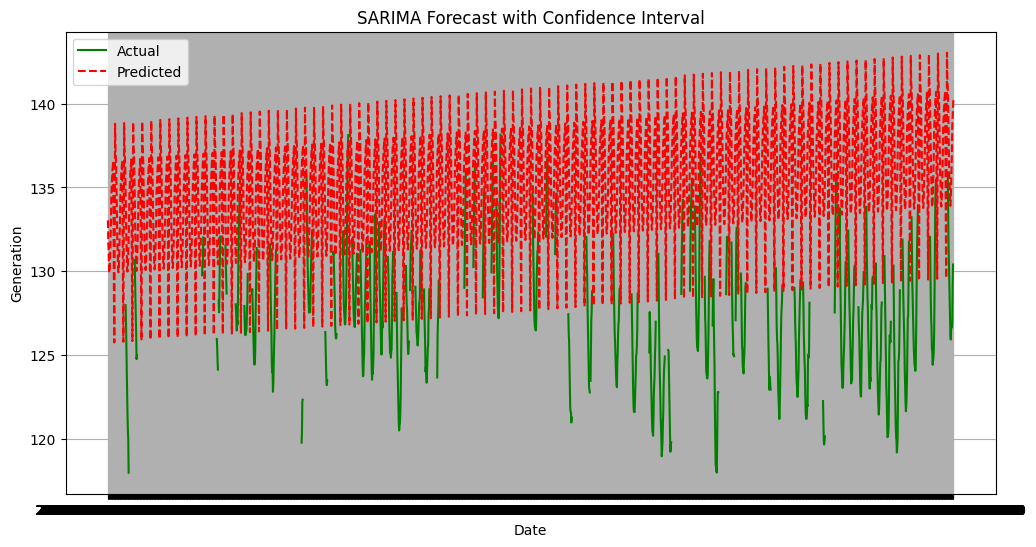

In [11]:
import matplotlib.pyplot as plt
conf_int = forecast_test.conf_int()

plt.figure(figsize=(12,6))

plt.plot(test_df['ds'], y_true_test, label='Actual', color='green')

plt.plot(test_df['ds'], y_pred_test, label='Predicted', color='red', linestyle='--')

# plt.fill_between(test_df['ds'], 
#                  conf_int.iloc[:,0],
#                  conf_int.iloc[:,1], 
#                  color='pink', alpha=0.3, label='95% CI')

plt.xlabel('Date')
plt.ylabel('Generation')
plt.title('SARIMA Forecast with Confidence Interval')
plt.legend()
plt.grid(True)
plt.show()